In [1]:
from transformers import CLIPTokenizer
from transformers import CLIPProcessor
from transformers import CLIPModel

import torch
import torch.nn.functional as F
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import requests
from io import BytesIO

#### Load Model

In [2]:
model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


#### Tokenize Text String

In [3]:
tokenzier = CLIPTokenizer.from_pretrained(model_name)

text = ["a donut", "a cookie", "an airplane", "a cat"]

inputs = tokenzier(text, padding=True, return_tensors="pt")

input_ids = inputs.input_ids

print("Input IDs (shape) ", input_ids.shape)
print(input_ids)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Input IDs (shape)  torch.Size([4, 4])
tensor([[49406,   320, 18471, 49407],
        [49406,   320,  9367, 49407],
        [49406,   550, 16451, 49407],
        [49406,   320,  2368, 49407]])


#### Find Text Embeddings

In [11]:
text_embeddings = None
with torch.no_grad():
    text_embeddings = model.get_text_features(**inputs)

text_embeddings = text_embeddings.pooler_output  # or last_hidden_state
print(text_embeddings.shape)

torch.Size([4, 512])


#### Calculate Cosine Similarity

In [12]:
cosine_similarity = F.cosine_similarity(
    text_embeddings[:,None,:],
    text_embeddings[None,:,:],
    dim = 2,
).cpu().numpy()

Text(45.72222222222221, 0.5, 'Text Embedding')

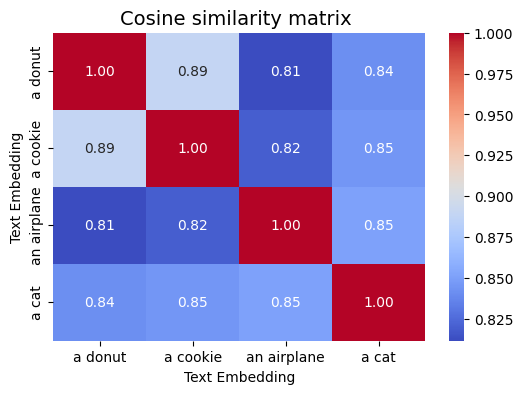

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cosine_similarity,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels = text,
    yticklabels = text
)

plt.title("Cosine similarity matrix ", fontsize=14)

plt.xlabel("Text Embedding")

plt.ylabel("Text Embedding")

#### Plot Images

In [20]:
def plot_images(images, label):
    n = len(images)

    fig, axes = plt.subplots(1,n)

    for ax, img, lbl in zip(axes, images, labels):
        ax.imshow(img)
        ax.set_title(lbl)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    

#### Load and Display images

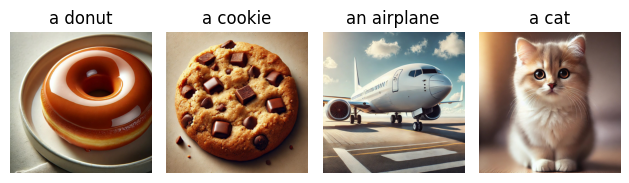

In [21]:
processor = CLIPProcessor.from_pretrained(model_name)

# Dictionary containing labels and their corresponding image URLs
image_urls = {
    "a donut": "https://learnopencv.com/wp-content/uploads/2025/03/donut.jpeg",
    "a cookie": "https://learnopencv.com/wp-content/uploads/2025/03/cookie.jpeg",
    "an airplane": "https://learnopencv.com/wp-content/uploads/2025/03/airplane.jpeg",
    "a cat": "https://learnopencv.com/wp-content/uploads/2025/03/cat.jpeg"
}

labels = list(image_urls.keys())

def load_image(url):
    headers = {'User-Agent': 'Mozilla/5.0'}        # Set headers to avoid blocking by web servers
    response = requests.get(url, headers=headers)  # Request the image from the URL
    response.raise_for_status()                    # Raise an error if the download fails
    # Open the downloaded image, convert it to RGB format, and return the PIL Image
    return Image.open(BytesIO(response.content)).convert("RGB")


images = []

for label in labels:
    try:
        img = load_image(image_urls[label])
        images.append(img)
    except:
        print(f"Failed to load {label}: {e}")

plot_images(images, labels)

#### Calculate Image Embeddings & Display Similarity 

In [26]:
image_inputs = processor(images=images, return_tensors='pt')

image_embeddings = None
with torch.no_grad():
    image_embeddings = model.get_image_features(**image_inputs)

image_embeddings = image_embeddings.pooler_output  # or last_hidden_state
print(image_embeddings.shape)

torch.Size([4, 512])


Text(45.72222222222221, 0.5, 'Text Embedding')

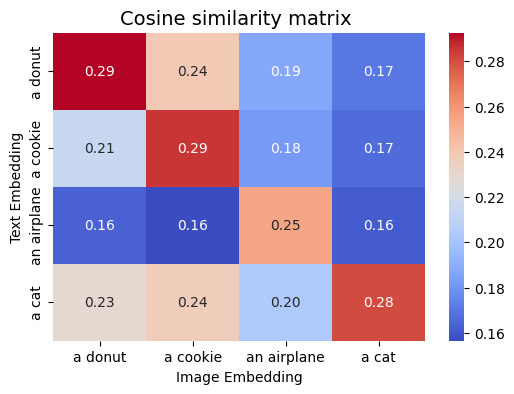

In [27]:
cosine_similarity = F.cosine_similarity(
    image_embeddings[:,None,:],
    text_embeddings[None,:,:],
    dim = 2,
).cpu().numpy()

plt.figure(figsize=(6,4))

sns.heatmap(
    cosine_similarity,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels = text,
    yticklabels = text
)

plt.title("Cosine similarity matrix ", fontsize=14)

plt.xlabel("Image Embedding")

plt.ylabel("Text Embedding")